ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

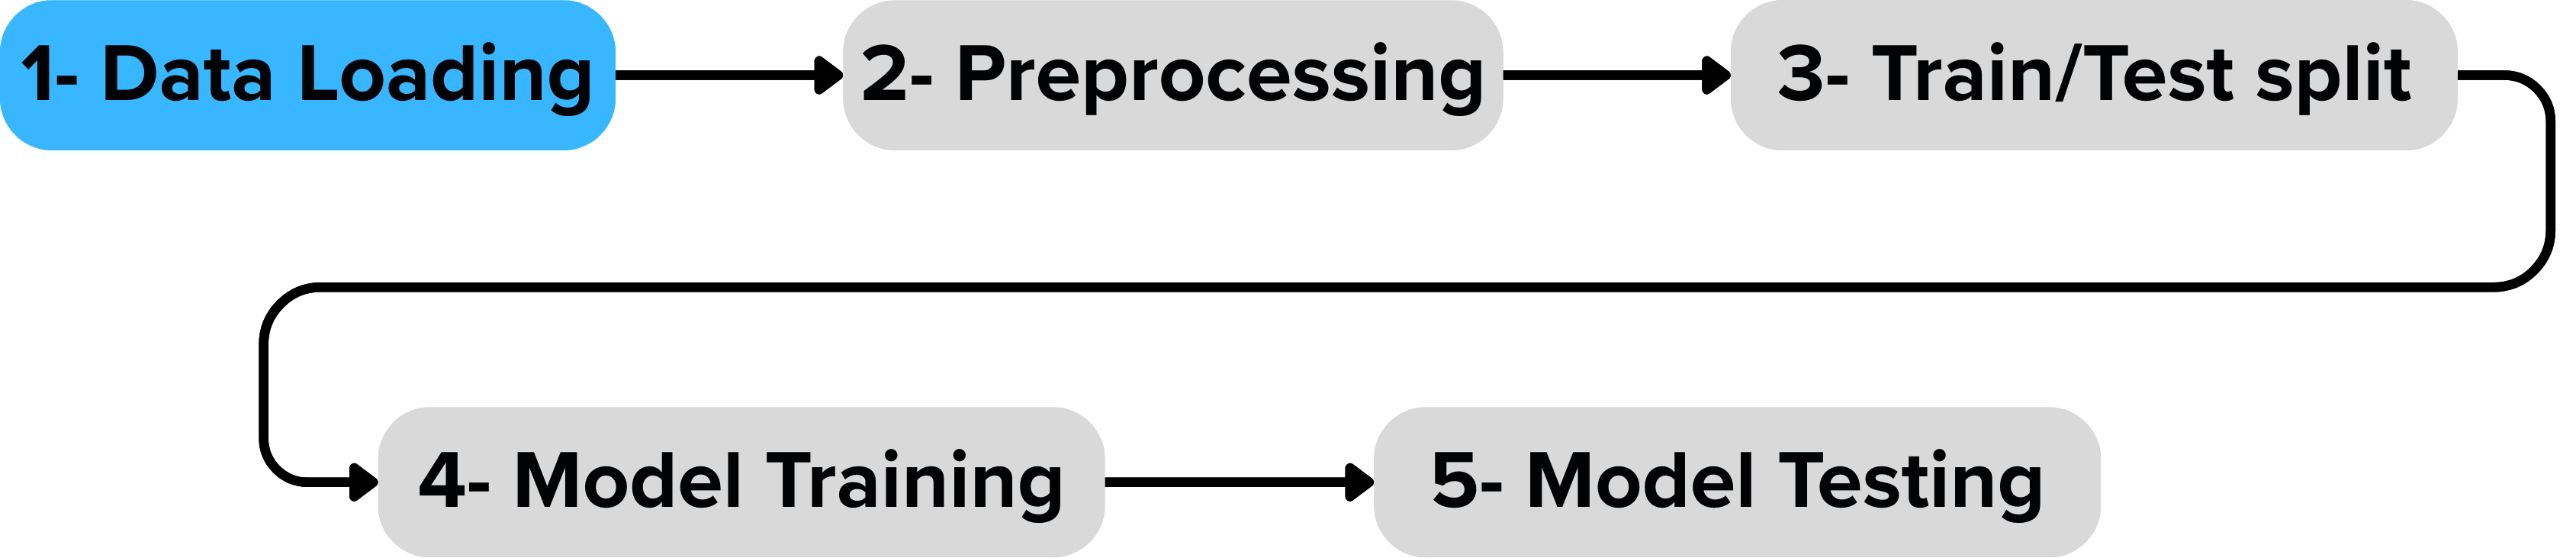

In [9]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [10]:
# Load Dataset

df = pd.read_csv(r"C:\Users\User\Desktop\ML DS.csv")

# Display first 5 rows
df.head()

,job_id,posting_year,country,region,city,company_name,company_size,industry,job_title,seniority_level,...,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,Brazil,South America,London,NextGen Technologies,Small,Education,Policy Analyst,Lead,...,0.81,"Research, Project Management, Business Analysis",reinforcement learning,61586,12.68,0.11,True,Low,14,Growing
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,UAE,Middle East,Singapore,Future Solutions,Medium,Energy,Data Scientist,Executive,...,0.04,"Research, SQL, Business Analysis, Python, Clou...",NaN,62045,-3.98,0.71,False,High,19,Emerging
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,Nepal,South Asia,Sydney,Future Analytics,Startup,Finance,Product Manager,Junior,...,0.15,"Statistics, Project Management, Cloud Computin...",NaN,27035,3.55,0.86,False,High,2,Emerging
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Spain,Europe,Nairobi,Global Technologies,Large,Government,Data Scientist,Mid,...,0.19,"Cloud Computing, SQL, Project Management, Comm...",NaN,72894,-2.80,0.70,False,Low,15,Emerging
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,Taiwan,East Asia,Sydney,Future Technologies,Small,Manufacturing,ML Engineer,Lead,...,0.11,"SQL, Python, Communication, Software Engineeri...",NaN,57215,0.85,0.87,False,High,13,Emerging


### Check Missing Values

In [11]:
# Check all values
print(df.isna())

      job_id  posting_year  country  region   city  company_name  \
0      False         False    False   False  False         False   
1      False         False    False   False  False         False   
2      False         False    False   False  False         False   
3      False         False    False   False  False         False   
4      False         False    False   False  False         False   
...      ...           ...      ...     ...    ...           ...   
4995   False         False    False   False  False         False   
4996   False         False    False   False  False         False   
4997   False         False    False   False  False         False   
4998   False         False    False   False  False         False   
4999   False         False    False   False  False         False   

      company_size  industry  job_title  seniority_level  ...  \
0            False     False      False            False  ...   
1            False     False      False            Fa

In [12]:
print(df.isna().sum())

job_id                                   0
posting_year                             0
country                                  0
region                                   0
city                                     0
company_name                             0
company_size                             0
industry                                 0
job_title                                0
seniority_level                          0
ai_mentioned                             0
ai_keywords                           3377
ai_intensity_score                       0
core_skills                              0
ai_skills                             3377
salary_usd                               0
salary_change_vs_prev_year_percent       0
automation_risk_score                    0
reskilling_required                      0
ai_job_displacement_risk                 0
job_description_embedding_cluster        0
industry_ai_adoption_stage               0
dtype: int64


### Check duplicate rows

In [13]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### No. of rows and columns

In [14]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (5000, 22) 

number of rows:  5000
number of columns:  22


### Data type of columns

In [15]:
# viewing the data types of columns
df.dtypes

job_id                                    str
posting_year                            int64
country                                   str
region                                    str
city                                      str
company_name                              str
company_size                              str
industry                                  str
job_title                                 str
seniority_level                           str
ai_mentioned                             bool
ai_keywords                               str
ai_intensity_score                    float64
core_skills                               str
ai_skills                                 str
salary_usd                              int64
salary_change_vs_prev_year_percent    float64
automation_risk_score                 float64
reskilling_required                      bool
ai_job_displacement_risk                  str
job_description_embedding_cluster       int64
industry_ai_adoption_stage        

In [16]:
# 1. Convert 'posting_year' to datetime format
df['posting_year'] = pd.to_datetime(df['posting_year'], format='%Y')

# 2. Clean 'salary_usd' (If it contains symbols, though your CSV looks clean)
# We use salary_usd instead of 'Amount'
df['salary_usd'] = pd.to_numeric(df['salary_usd'], errors='coerce')

# 3. Check data types
print(df.dtypes)

job_id                                           str
posting_year                          datetime64[us]
country                                          str
region                                           str
city                                             str
company_name                                     str
company_size                                     str
industry                                         str
job_title                                        str
seniority_level                                  str
ai_mentioned                                    bool
ai_keywords                                      str
ai_intensity_score                           float64
core_skills                                      str
ai_skills                                        str
salary_usd                                     int64
salary_change_vs_prev_year_percent           float64
automation_risk_score                        float64
reskilling_required                           

### Descriptive summary Statistics

In [17]:
# Statistical summary
df.describe(include='all')

,job_id,posting_year,country,region,city,company_name,company_size,industry,job_title,seniority_level,...,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,...,5000.000000,5000,1623,5000.00000,5000.000000,5000.000000,5000,5000,5000.000000,5000
unique,5000,NaN,44,9,14,16,5,9,10,6,...,NaN,4162,617,NaN,NaN,NaN,2,3,NaN,3
top,836b4774-702e-49ef-93d3-2f255ce1e910,NaN,Australia,South America,Toronto,Prime Systems,Small,Tech,ML Engineer,Executive,...,NaN,"SQL, Project Management, Research",deep learning,NaN,NaN,NaN,False,Low,NaN,Growing
freq,1,NaN,281,601,390,331,1031,579,558,856,...,NaN,8,72,NaN,NaN,NaN,3377,1718,NaN,2502
mean,NaN,2017-07-09 08:05:51.360000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.287312,NaN,NaN,63096.18480,3.015192,0.586176,NaN,NaN,9.473000,NaN
min,NaN,2010-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,15321.00000,-5.000000,0.100000,NaN,NaN,0.000000,NaN
25%,NaN,2013-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.070000,NaN,NaN,36575.50000,-1.580000,0.330000,NaN,NaN,4.000000,NaN
50%,NaN,2017-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.150000,NaN,NaN,60909.50000,1.720000,0.670000,NaN,NaN,10.000000,NaN
75%,NaN,2022-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.520000,NaN,NaN,81811.75000,5.385000,0.790000,NaN,NaN,14.000000,NaN
max,NaN,2025-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.950000,NaN,NaN,161547.00000,17.980000,0.900000,NaN,NaN,19.000000,NaN


### Univariate Analysis

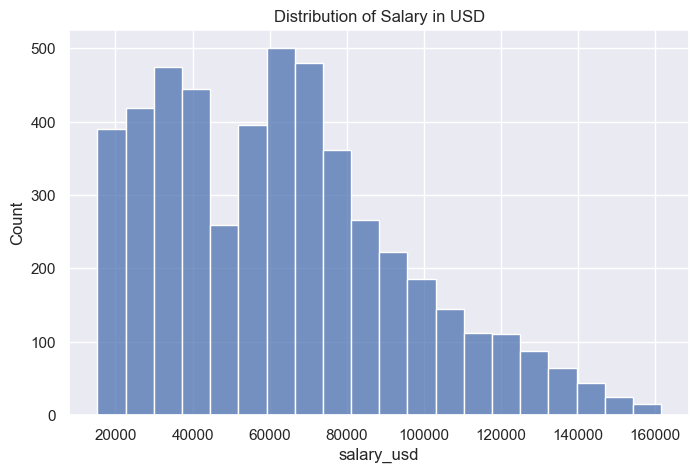

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['salary_usd'], bins=20)
plt.title("Distribution of Salary in USD")
plt.show()

### Distribution of Industry AI Adoption Stage

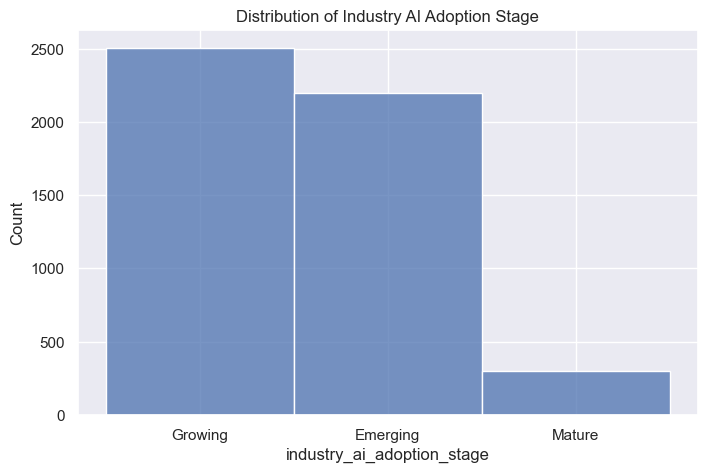

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['industry_ai_adoption_stage'], bins=20)
plt.title("Distribution of Industry AI Adoption Stage")
plt.show()

## Bivariate Analysis

### Top 15 Countries by Average Salary (USD)

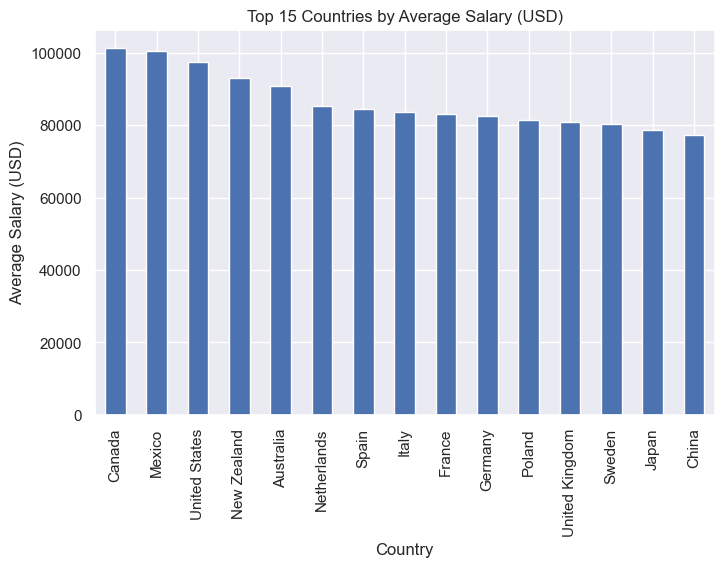

In [26]:
df['salary_usd'] = pd.to_numeric(df['salary_usd'], errors='coerce')

# 3. Exploratory Data Analysis (EDA)
# We calculate Average Salary and take the Top 15 countries for a cleaner chart
country_avg_salary = df.groupby('country')['salary_usd'].mean().sort_values(ascending=False).head(15)

# 4. Visualization
plt.figure(figsize=(8,5))
country_avg_salary.plot(kind='bar')

plt.title("Top 15 Countries by Average Salary (USD)")
plt.xlabel("Country")
plt.ylabel("Average Salary (USD)")
plt.show()





### Total Salary Expenditure by Industry

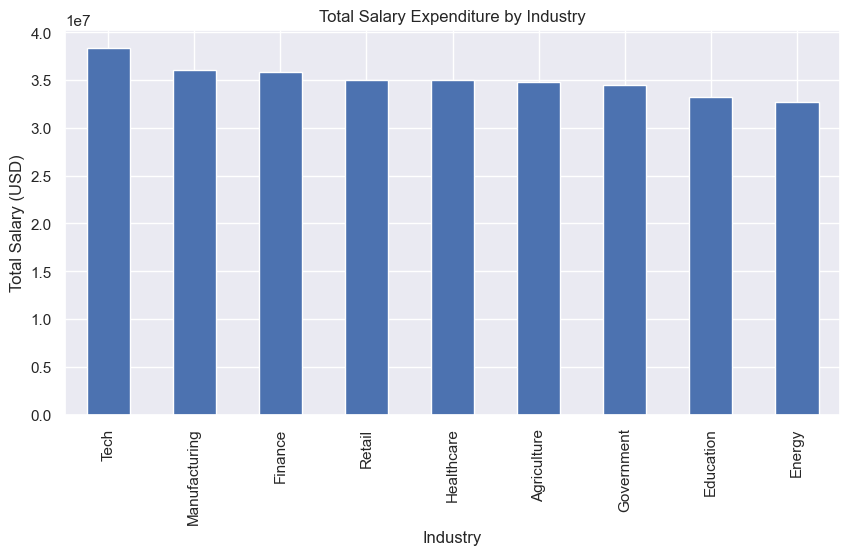

industry
Tech             38365705
Manufacturing    36031438
Finance          35837039
Retail           35053199
Healthcare       35001144
Agriculture      34780139
Government       34446493
Education        33222872
Energy           32742895
Name: salary_usd, dtype: int64


In [27]:
industry_salary = df.groupby('industry')['salary_usd'].sum().sort_values(ascending=False)

# Visualization
plt.figure(figsize=(10,5))
industry_salary.plot(kind='bar')

plt.title("Total Salary Expenditure by Industry")
plt.xlabel("Industry")
plt.ylabel("Total Salary (USD)")

plt.show()

print(industry_salary)

### Top 10 job titles by total salary

In [22]:
# Grouping by Job Title and summing the Salary
job_title_salary = df.groupby('job_title')['salary_usd'].sum().sort_values(ascending=False)

# Display the top 10 job titles by total salary
job_title_salary.head(10)

job_title
ML Engineer           36129612
Operations Manager    33937119
AI Researcher         31624237
Systems Engineer      31545650
Data Scientist        31461444
Research Scientist    31461268
Software Engineer     31434367
Business Analyst      30407922
Policy Analyst        29853000
Product Manager       27626305
Name: salary_usd, dtype: int64

### AI Intensity vs Salary (USD)

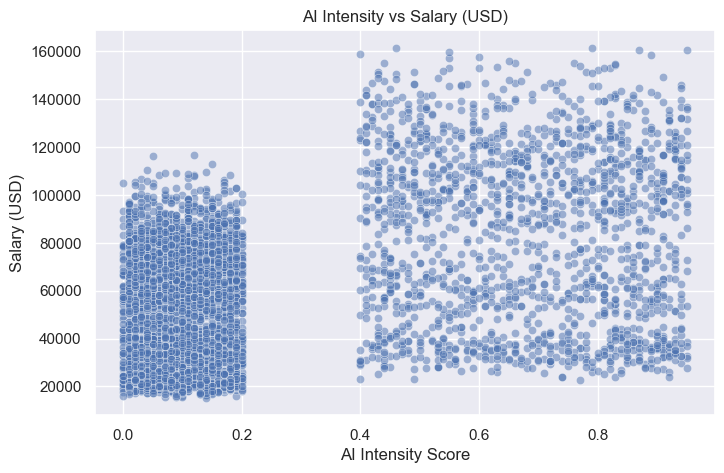

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='ai_intensity_score', y='salary_usd', data=df, alpha=0.5)

plt.title("AI Intensity vs Salary (USD)")
plt.xlabel("AI Intensity Score")
plt.ylabel("Salary (USD)")
plt.show()

### Correlation Matrix

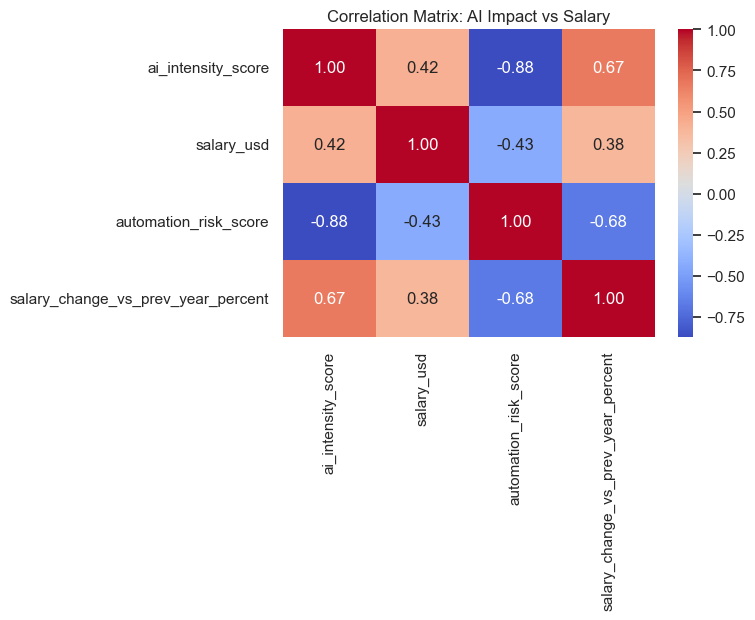

In [28]:
cols = ['ai_intensity_score', 'salary_usd', 'automation_risk_score', 'salary_change_vs_prev_year_percent']

# 2. Creating the Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix: AI Impact vs Salary")
plt.show()



## Time-Based Analysis
### Yearly Salary Expenditure Trend

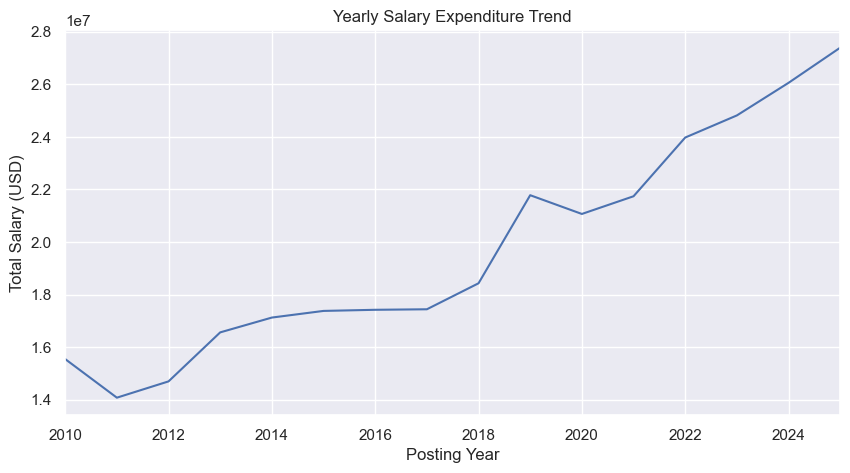

In [29]:
# 1. Grouping by Year and summing Salary
yearly_salary = df.groupby('posting_year')['salary_usd'].sum()

# 2. Plotting the Yearly Trend
plt.figure(figsize=(10,5))
yearly_salary.plot(kind='line')

plt.title("Yearly Salary Expenditure Trend")
plt.xlabel("Posting Year")
plt.ylabel("Total Salary (USD)")

plt.show()



# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the dataset file with your notebook.


End of lab 3.